In [23]:
import pandas as pd
import numpy as np
import time
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

In [24]:
import importlib
import feature_engineer
importlib.reload(feature_engineer)

<module 'feature_engineer' from '/Users/jiashenwang/Desktop/Lucas_Systems_Capstone_Project/Model_Jiashen/feature_engineer.py'>

In [25]:
# Configurations
warehouses = ["OE", "OF"]
work_codes = ["10", "20", "30"]
warehouses = ["RT"]
work_codes = ["1", "2", "3", "4", "5", "6", "11"]
max_time = 300
models = []
results = []

In [26]:
from feature_engineer import get_engineered_df

for wh in warehouses:
    DATA_PATH = f"../data/processed/{wh.lower()}_detailed.parquet"
    for wc in work_codes:
        print(f"--- Training Model for {wh} | WC {wc} ---")
        
        # 1. Preprocess
        df, features, cat_cols = get_engineered_df(DATA_PATH, warehouse=wh, work_code=wc, max_time=max_time, sequenced=True)
        
        # 2. Prepare Data (One-Hot Encoding)
        X = pd.get_dummies(df[features], columns=cat_cols, drop_first=True)
        y = df["Time_Delta_sec"]
        
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        
        # 3. Model Training & Timing
        start_time = time.time()
        model = XGBRegressor(n_estimators=1000, learning_rate=0.05, max_depth=6, random_state=42, n_jobs=-1)
        model.fit(X_train, y_train)
        end_time = time.time()
        models.append(model)
        
        # 4. Evaluation
        preds = model.predict(X_test)
        r2 = r2_score(y_test, preds)
        mae = mean_absolute_error(y_test, preds)
        runtime = end_time - start_time
        
        # 5. Store Results
        results.append({
            "Warehouse": wh,
            "WorkCode": wc,
            "Train_Rows": len(X_train),
            "R^2": round(r2, 4),
            "MAE": round(mae, 2),
            "Runtime_Sec": round(runtime, 2)
        })

# Display Clean Results Table
results_df = pd.DataFrame(results)
display(results_df)

--- Training Model for RT | WC 1 ---
--- Training Model for RT | WC 2 ---
--- Training Model for RT | WC 3 ---
--- Training Model for RT | WC 4 ---
--- Training Model for RT | WC 5 ---
--- Training Model for RT | WC 6 ---
--- Training Model for RT | WC 11 ---


,Warehouse,WorkCode,Train_Rows,R^2,MAE,Runtime_Sec
0,RT,1,5281,0.1520,13.62,0.59
1,RT,2,7432,0.1699,17.52,0.64
2,RT,3,4807,0.0260,20.86,0.87
3,RT,4,7684,0.0662,19.71,1.02
4,RT,5,12892,0.2467,14.57,0.67
5,RT,6,19568,0.3141,22.66,0.99
6,RT,11,5440,0.1639,34.61,0.85


In [27]:
models_nodist = []
results_nodist = []

for wh in warehouses:
    DATA_PATH = f"../data/processed/{wh.lower()}_detailed.parquet"
    for wc in work_codes:
        print(f"--- Training Model for {wh} | WC {wc} ---")
        
        # 1. Preprocess
        df, features, cat_cols = get_engineered_df(DATA_PATH, warehouse=wh, work_code=wc, max_time=max_time)
        # remove distance, "same_aisle", "same_lockey", "same_level" from features
        features = [f for f in features if f not in ["Travel_Distance", "same_aisle", "same_lockey", "same_level"]]
        cat_cols = [col for col in cat_cols if col not in ["same_aisle", "same_lockey", "same_level"]]
        
        # 2. Prepare Data (One-Hot Encoding)
        X = pd.get_dummies(df[features], columns=cat_cols, drop_first=True)
        y = df["Time_Delta_sec"]
        
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        
        # 3. Model Training & Timing
        start_time = time.time()
        model = XGBRegressor(n_estimators=1000, learning_rate=0.05, max_depth=6, random_state=42, n_jobs=-1)
        model.fit(X_train, y_train)
        end_time = time.time()
        models_nodist.append(model)
        
        # 4. Evaluation
        preds = model.predict(X_test)
        r2 = r2_score(y_test, preds)
        mae = mean_absolute_error(y_test, preds)
        runtime = end_time - start_time
        
        # 5. Store Results
        results_nodist.append({
            "Warehouse": wh,
            "WorkCode": wc,
            "Train_Rows": len(X_train),
            "R^2": round(r2, 4),
            "MAE": round(mae, 2),
            "Runtime_Sec": round(runtime, 2)
        })

# Display Clean Results Table
results_df_nodist = pd.DataFrame(results_nodist)
display(results_df_nodist)

--- Training Model for RT | WC 1 ---
--- Training Model for RT | WC 2 ---
--- Training Model for RT | WC 3 ---
--- Training Model for RT | WC 4 ---
--- Training Model for RT | WC 5 ---
--- Training Model for RT | WC 6 ---
--- Training Model for RT | WC 11 ---


,Warehouse,WorkCode,Train_Rows,R^2,MAE,Runtime_Sec
0,RT,1,5281,-0.0521,15.64,0.77
1,RT,2,7432,0.0392,19.05,0.79
2,RT,3,4807,-0.1551,23.15,0.62
3,RT,4,7684,-0.0847,22.06,0.53
4,RT,5,12892,-0.0408,19.15,0.65
5,RT,6,19568,0.0628,29.36,0.89
6,RT,11,5440,0.0045,39.24,0.61


In [28]:
# Append MAE column of nodist to original results_df, right after MAE column and befoire Runtime_Sec, also add percentage increase
display_df = results_df.copy()
display_df["MAE_noDist"] = results_df_nodist["MAE"]
display_df["MAE_Increase(%)"] = ((display_df["MAE_noDist"] - display_df["MAE"]) / display_df["MAE"] * 100).round(2)
# move Runtime_Sec column to the end
cols = list(display_df.columns)
cols.append(cols.pop(cols.index("Runtime_Sec")))
display_df = display_df[cols]
display(display_df) 

,Warehouse,WorkCode,Train_Rows,R^2,MAE,MAE_noDist,MAE_Increase(%),Runtime_Sec
0,RT,1,5281,0.1520,13.62,15.64,14.83,0.59
1,RT,2,7432,0.1699,17.52,19.05,8.73,0.64
2,RT,3,4807,0.0260,20.86,23.15,10.98,0.87
3,RT,4,7684,0.0662,19.71,22.06,11.92,1.02
4,RT,5,12892,0.2467,14.57,19.15,31.43,0.67
5,RT,6,19568,0.3141,22.66,29.36,29.57,0.99
6,RT,11,5440,0.1639,34.61,39.24,13.38,0.85


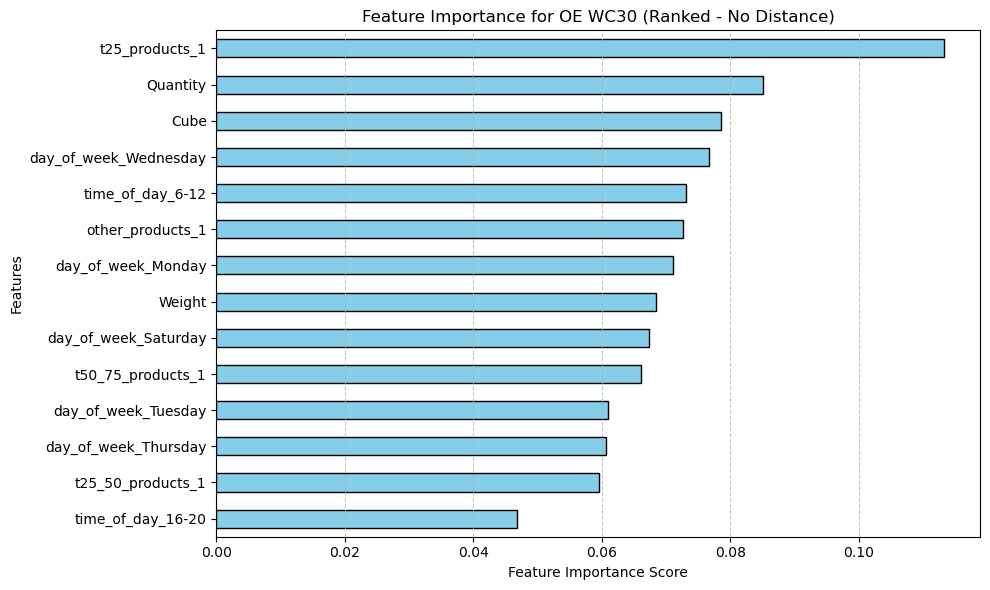

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Select the model
oe_wc30_model_nodist = models_nodist[2]

# 2. Create a Series using the model's internal feature names to prevent index mismatch
feat_importances = pd.Series(
    oe_wc30_model_nodist.feature_importances_, 
    index=oe_wc30_model_nodist.feature_names_in_
).sort_values(ascending=True)

# 3. Plotting
plt.figure(figsize=(10, 6))
feat_importances.plot(kind='barh', color='skyblue', edgecolor='black')

plt.xlabel("Feature Importance Score")
plt.ylabel("Features")
plt.title("Feature Importance for OE WC30 (Ranked - No Distance)")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

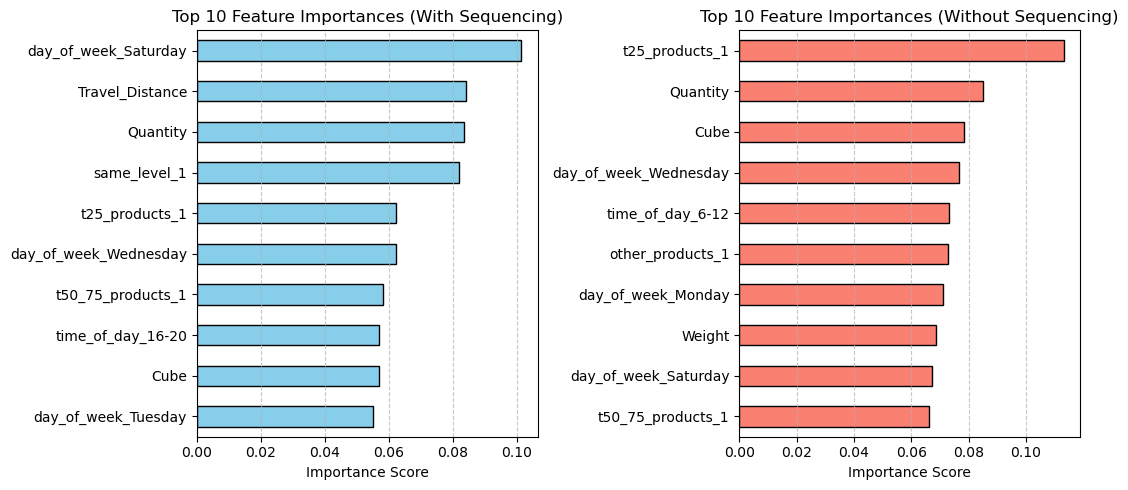

In [30]:
# Side by side bar charts for original model and no-distance model, top 10 features
oe_wc30_model = models[2]
feat_importances_orig = pd.Series(
    oe_wc30_model.feature_importances_, 
    index=oe_wc30_model.feature_names_in_
).sort_values(ascending=True)

oe_wc30_model_nodist = models_nodist[2]
feat_importances_nodist = pd.Series(
    oe_wc30_model_nodist.feature_importances_, 
    index=oe_wc30_model_nodist.feature_names_in_
).sort_values(ascending=True)

top10_orig = feat_importances_orig.tail(10)
top10_nodist = feat_importances_nodist.tail(10)
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
top10_orig.plot(kind='barh', color='skyblue', edgecolor='black', ax=axes[0])
axes[0].set_title("Top 10 Feature Importances (With Sequencing)")
axes[0].set_xlabel("Importance Score")
axes[0].grid(axis='x', linestyle='--', alpha=0.7)
top10_nodist.plot(kind='barh', color='salmon', edgecolor='black', ax=axes[1])
axes[1].set_title("Top 10 Feature Importances (Without Sequencing)")
axes[1].set_xlabel("Importance Score")
axes[1].grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()